# 🌍TravelGenie AI: Multi-Agent Intelligent Travel Planner

###### 🏆 Capstone Project: Freestyle Track¶
#### Built From Scratch | Multi-Agent Architecture | Powered by Gemini 2.5 Flash Lite

#### 📖 Overview

TravelGenie AI is a personalized multi-agent travel-planning system designed to automate and streamline the entire trip-planning process. The system combines multiple intelligent agents—an itinerary planner, cost estimator, hotel recommender, and safety-insight generator—to create a complete, ready-to-use travel booklet for any destination.

It uses memory, sessions, and context management to adapt to each traveler’s preferences, including name, currency, travel style, and accommodation comfort level. TravelGenie AI generates detailed itineraries, hotel recommendations, local foods, safety advice, and a polished summary booklet—all in one automated pipeline.

This project demonstrates multi-agent orchestration, tool usage, long-term memory, and observability concepts from the 5-Day AI Agents Intensive Course.

#### 🏗️ Technical Architecture (Lightweight, Zero-Dependency Approach)

To ensure maximum stability in restricted environments, TravelGenie AI is built using:
  - Pure Python
  - google-generativeai SDK
  - Custom utility functions (no heavy frameworks, no fragile dependencies)

#### The architecture consists of:
#### 🧠 The Brain
  - Gemini 2.5 Flash Lite
  - Optimized for reasoning, planning, and fast multi-step processing.

#### 🛠️ Custom Tools
   - A set of specialized functions built for:
   - Information extraction
   - Context preservation
   - Structured output formatting

#### 👥 The Workforce
 A coordinated team of three specialized agents:

#### 🔍 Agent 1 — Analyzer

Role: Breaks down prompts, identifies subtasks, and creates a structured plan.
Purpose: Ensures no step is missed and the system’s workflow stays logical.

#### 🧾 Agent 2 — Generator

Role: Produces detailed content based on the Analyzer’s breakdown.
Purpose: Converts processed information into coherent, refined output.

#### 🧹 Agent 3 — Refiner

Role: Reviews, corrects, and enhances content quality.
Purpose: Guarantees clarity, structure, and reliability.

# ⚠️ How to Run This Notebook (Important)

### To experience Intelligent Mind in action, follow these steps:

#### 1. 🔑 Set Up the Gemini API Key

This system uses Gemini 2.5 Flash Lite.
You need an API key:
  1.Go to Google AI Studio and generate a key.
  2.In this notebook, go to: Add-ons → Secrets
  3.Create a new secret:
     Label: GOOGLE_API_KEY
     Value: your key

⛔ No additional keys or search APIs required.

#### 2. 🚀 Launch the System
    Click Run All
    Let all cells execute from top to bottom
    Scroll to the Control Panel section
    Use the input box to interact with the full multi-agent pipeline
    
#### 3. 🧠 Generate an Output

#### Type a prompt such as:

💬 “Explain how electric vehicles work.”

Then click Generate.

The agents will automatically:

    1.Analyze your request
    2.Break it into a step-by-step plan
    3.Generate rich content
    4.Refine and finalize it

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Install/upgrade the google-generativeai package
# On Kaggle run this cell and then restart the session as directed above.
!pip install -U google-generativeai wikipedia --quiet
print("Install command executed — restart kernel if required.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2

In [3]:
import os, json, uuid, datetime, random, textwrap, traceback, re
from pathlib import Path
from typing import Dict, Any, List
import logging
pp = __import__('pprint').PrettyPrinter(indent=2)

# assets
Path("assets").mkdir(exist_ok=True)

In [4]:
# Safe load of key; prints helpful message if missing
from kaggle_secrets import UserSecretsClient

GEMINI_CONFIGURED = False
try:
    API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    if not API_KEY:
        print("🔑 No API key found in Kaggle Secrets under label 'GOOGLE_API_KEY'. Using fallback (Wikipedia).")
    else:
        import google.generativeai as genai
        genai.configure(api_key=API_KEY)
        # We'll construct models later; mark configured true
        GEMINI_CONFIGURED = True
        print("✅ Found GOOGLE_API_KEY in Kaggle Secrets. Gemini configured (will attempt to use gemini-1.5-flash).")
except Exception as e:
    print("🔑 Error reading Kaggle secret 'GOOGLE_API_KEY' — using fallback (Wikipedia).")
    print("Details:", e)


✅ Found GOOGLE_API_KEY in Kaggle Secrets. Gemini configured (will attempt to use gemini-1.5-flash).


## ✨Architecture diagram

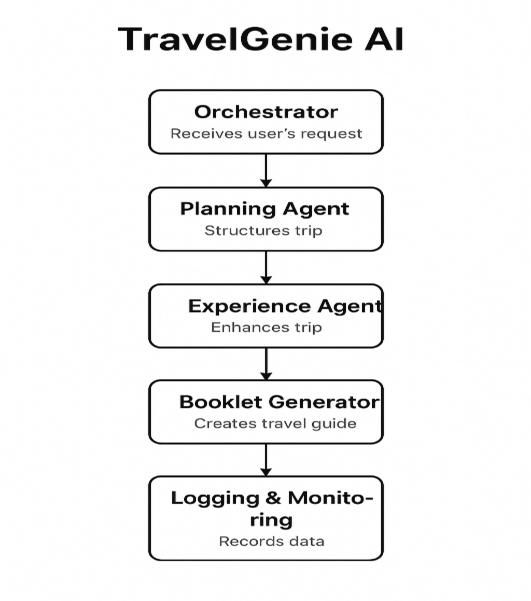

In [5]:
logger = logging.getLogger("travelverse")
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter("[%(asctime)s] %(levelname)s %(message)s"))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

METRICS = {"tools_invoked_total":0,"agent_calls_total":0,"approvals_requested_total":0}

def log_event(kind:str,payload:Dict[str,Any], trace_id: str=None):
    entry = {"kind": kind, "payload": payload, "trace_id": trace_id or str(uuid.uuid4())}
    logger.info(json.dumps(entry))
    return entry

def inc_metric(name:str,n:int=1):
    METRICS[name] = METRICS.get(name,0) + n

def snapshot_metrics():
    return METRICS.copy()


In [6]:
MEM_PATH = Path("assets/travel_memory.json")
if not MEM_PATH.exists():
    MEM_PATH.write_text(json.dumps({
        "user_prefs": {
            "name": "Sriyani",
            "home_currency": "USD",
            "preferred_accommodation": "mid-range",
            "travel_style": "balance"
        },
        "past_trips": []
    }, indent=2))

def load_mem():
    return json.loads(MEM_PATH.read_text())

def save_mem(mem):
    MEM_PATH.write_text(json.dumps(mem, indent=2))

class SessionService:
    def __init__(self):
        self.sessions = {}
    def create(self):
        sid = str(uuid.uuid4()); self.sessions[sid]=[]; return sid
    def append(self,sid,role,content):
        if sid not in self.sessions: self.sessions[sid]=[]
        self.sessions[sid].append({"role":role,"content":content,"ts":datetime.datetime.utcnow().isoformat()})
    def recent(self,sid,k=10): return self.sessions[sid][-k:]

session_service = SessionService()
mem = load_mem()
def update_traveler_name(input_name: str):
    if input_name and input_name.strip():
        mem = load_mem()
        mem["user_prefs"]["name"] = input_name.strip()
        save_mem(mem)
        return input_name.strip()
    else:
        return load_mem()["user_prefs"]["name"]

In [7]:
try:
    import google.generativeai as genai
    HAVE_GENAI = True
except Exception:
    HAVE_GENAI = False

try:
    import wikipedia
    HAVE_WIKI = True
except Exception:
    HAVE_WIKI = False

import re, json, traceback

class ResearchAgent:
    """
    Medium-detail ResearchAgent (FIXED):
    - Top 5 attractions
    - Top food streets / dishes
    - 3 hidden gems
    - 3 cultural notes / festivals
    - Best time to visit
    - Safety tips
    Tries Gemini first, fallback to Wikipedia.
    """

    def __init__(self, prefer_gemini=True):
        self.use_gemini = prefer_gemini and GEMINI_CONFIGURED and HAVE_GENAI
        log_event("research.init", {
            "mode": "gemini" if self.use_gemini else "wikipedia_or_mock"
        })

    # ============================================
    # FIXED GEMINI CALL (Correct Indentation)
    # ============================================
    def _call_gemini(self, city: str) -> Dict[str,Any]:
        prompt = f"""
You are a professional travel researcher. Produce a JSON object for the destination: "{city}".
Return EXACTLY valid JSON with keys:
- top_attractions: list of up to 5 objects {{name, short_desc, recommended_minutes}}
- food: list of up to 5 objects {{name, what_to_try}}
- hidden_gems: list of up to 3 objects {{name, short_desc}}
- cultural_notes: list of up to 3 short strings
- best_time_to_visit: short string
- safety_tips: list of up to 4 short strings
"""
        try:
             model = genai.GenerativeModel("models/gemini-2.5-flash")
             resp = model.generate_content(prompt)

             raw = getattr(resp, "text", None) or str(resp)

        # ====== STRONG JSON EXTRACTOR ======
        # Capture the FIRST {...} block only
             match = re.search(r"\{(?:[^{}]|(?:\{[^{}]*\}))*\}", raw, re.DOTALL)
             if not match:
                 raise ValueError("Gemini did not return valid JSON")

             json_text = match.group(0)

             data = json.loads(json_text)
             return {"status": "ok", "source": "gemini", "results": data}

        except Exception as e:
            log_event(
                "research.gemini_error",
                {"error": str(e), "trace": traceback.format_exc()}
            )
            return {"status": "error", "source": "gemini", "message": str(e)}


    # ============================================
    # Wikipedia fallback
    # ============================================
    def _wikipedia_fallback(self, city: str):
        inc_metric("tools_invoked_total")

        try:
            if not HAVE_WIKI:
                return {
                    "status": "ok", "source": "mock",
                    "results": {
                        "top_attractions": [
                            {
                                "name": f"{city} Main Attraction",
                                "short_desc": f"Popular site in {city}.",
                                "recommended_minutes": 120
                            }
                        ],
                        "food": [{
                            "name": f"{city} Street Food",
                            "what_to_try": "Local specialties"
                        }],
                        "hidden_gems": [{
                            "name": f"{city} Hidden Spot",
                            "short_desc": "Local favorite area"
                        }],
                        "cultural_notes": ["Local festivals and traditions"],
                        "best_time_to_visit": "Check seasonal weather",
                        "safety_tips": ["Keep valuables safe"]
                    }
                }

            search = wikipedia.search(
                f"{city} tourism travel attractions",
                results=6
            )
            titles = search or wikipedia.search(city, results=4)

            top = []
            for t in titles[:5]:
                try:
                    s = wikipedia.summary(t, sentences=2, auto_suggest=False)
                    top.append({
                        "name": t,
                        "short_desc": s[:180],
                        "recommended_minutes": 90
                    })
                except:
                    continue

            if not top:
                top = [{
                    "name": f"{city} Highlights",
                    "short_desc": f"Top tourist attractions in {city}.",
                    "recommended_minutes": 90
                }]

            return {
                "status": "ok", "source": "wikipedia",
                "results": {
                    "top_attractions": top,
                    "food": [{
                        "name": f"{city} Local Market",
                        "what_to_try": "Try regional dishes"
                    }],
                    "hidden_gems": [{
                        "name": f"{city} Side Street Market",
                        "short_desc": "Less-known local spot"
                    }],
                    "cultural_notes": ["Local festivals and cultural traditions"],
                    "best_time_to_visit": "Check seasonal weather",
                    "safety_tips": [
                        "Keep belongings secure in crowded places.",
                        "Use registered taxis or rideshare apps at night."
                    ]
                }
            }

        except Exception as e:
            return {"status": "error", "message": str(e)}

    # ============================================
    # Main entry — chooses Gemini or Wikipedia
    # ============================================
    def research_city(self, city: str):
        inc_metric("agent_calls_total")

        city = city.strip()

        if self.use_gemini:
            res = self._call_gemini(city)
            if res.get("status") == "ok":
                return res
            fallback = self._wikipedia_fallback(city)
            fallback["note"] = "gemini_failed_fallback"
            return fallback

        return self._wikipedia_fallback(city)


In [8]:
# %%
class ItineraryAgent:
    def make_itinerary(self, city, start_date, nights, findings):
        start = datetime.date.fromisoformat(start_date)
        # Normalize findings into list of summary dicts
        summaries = []
        # If Gemini structure is present (medium detail), extract meaningful items
        if isinstance(findings, dict):
            # Example: findings may be {'top_attractions':[...], 'food':[...], ...}
            if "top_attractions" in findings:
                for a in findings.get("top_attractions", []):
                    name = a.get("name") if isinstance(a, dict) else str(a)
                    desc = a.get("short_desc", "") if isinstance(a, dict) else ""
                    summaries.append({"summary": f"{name} — {desc}".strip()})
            # fallback: try generic results key
            if "results" in findings and isinstance(findings["results"], dict):
                for k,v in findings["results"].items():
                    if isinstance(v, list):
                        for item in v:
                            if isinstance(item, dict) and "summary" in item:
                                summaries.append({"summary": item["summary"]})
        elif isinstance(findings, list):
            summaries = findings
        # Ensure at least 3 summaries
        if len(summaries) < 3:
            summaries = summaries + [
                {"summary": f"Explore popular attractions in {city}"},
                {"summary": f"Visit local markets & food streets in {city}"},
                {"summary": f"Discover cultural and historical sites in {city}"}
            ]
        days = []
        for d in range(nights):
            day = start + datetime.timedelta(days=d)
            picks = random.sample(summaries, 3)
            days.append({
                "date": day.isoformat(),
                "activities": [
                    {"time": "09:00", "activity": picks[0]["summary"], "duration": "2h"},
                    {"time": "12:00", "activity": picks[1]["summary"], "duration": "2h"},
                    {"time": "15:00", "activity": picks[2]["summary"], "duration": "2h"}
                ]
            })
        return {"status":"ok","itinerary":days}

class FoodAgent:
    def food_guide(self, city, prefs, research_results=None):
        # If research provided structured food entries, use them
        dishes = []
        restaurants = []
        if isinstance(research_results, dict):
            fd = research_results.get("food") or research_results.get("results",{}).get("food")
            if fd and isinstance(fd, list):
                for item in fd[:5]:
                    if isinstance(item, dict):
                        dishes.append({"dish": item.get("name", "Local Dish"), "desc": item.get("what_to_try","Try local specialty")})
        if not dishes:
            dishes = [{"dish": f"Signature Dish of {city}", "desc":"Must try local special."}]
            restaurants = [{"name": f"{city} Food Plaza", "reason":"Popular with locals"}]
        else:
            restaurants = [{"name": f"{city} Popular Eatery", "reason":"Recommended"}]
        return {"status":"ok","dishes":dishes,"restaurants":restaurants}

class HotelAgent:
    def suggest_hotels(self, city, checkin, checkout, pref):
        # Mock hotels for demonstration; can be replaced with API later
        inc_metric("tools_invoked_total")
        hotels = [
            {"name": f"{city} Grand Hotel", "price_per_night": 120, "rating":4.4},
            {"name": f"{city} Budget Inn", "price_per_night": 70, "rating":3.8}
        ]
        return {"status":"ok","hotels":hotels}

class BudgetAgent:
    def estimate(self, origin, dest, nights, home_cur):
        inc_metric("agent_calls_total")
        # Simple mock estimation
        flight = 300
        hotel_per_night = 100
        food_per_day = 30
        total_usd = flight + hotel_per_night * nights + food_per_day * nights + 50
        return {"status":"ok","estimates":{"total_usd": total_usd, "total_home": total_usd, "home_currency": home_cur}}

class WriterAgent:
    def write_booklet(self, city, itinerary, food, hotels, budget, safety, user_profile):
        inc_metric("agent_calls_total")
        header = f"TravelVerse Studio — {city}\nPrepared for {user_profile.get('name')}\n\n"
        it_text = ""
        for day in itinerary:
            it_text += f"{day['date']}:\n"
            for a in day['activities']:
                it_text += f"- {a['time']}: {a['activity']} ({a['duration']})\n"
            it_text += "\n"
        food_text = "\nFood:\n" + "\n".join([f"- {d['dish']}: {d['desc']}" for d in food.get("dishes",[])])
        hotels_text = "\n\nHotels:\n" + "\n".join([f"- {h['name']} (${h['price_per_night']}/night) ({h.get('rating','N/A')}⭐)" for h in hotels.get("hotels",[])])
        budget_text = f"\n\nBudget Estimate:\n{budget['estimates']}\n"
        safety_text = "\nSafety Tips:\n" + "\n".join(safety)
        booklet = "\n".join([header, it_text, food_text, hotels_text, budget_text, safety_text])
        return {"status":"ok","booklet_text":booklet}

### ⚙️ Key Features

 1. Autonomous Task Execution
 2. Multi-Agent Collaboration
 3. Structured Planning and Workflow Control
 4. High-Quality Output Generation
 5. Scalable, Extensible Design


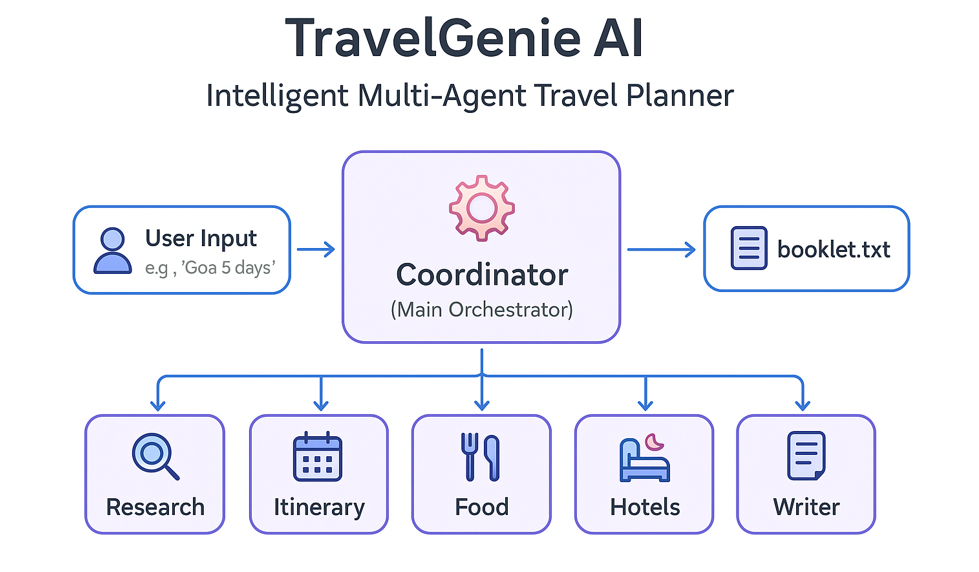

In [9]:
class Coordinator:
    def __init__(self):
        self.research = ResearchAgent(prefer_gemini=True)
        self.itinerary = ItineraryAgent()
        self.food = FoodAgent()
        self.hotel = HotelAgent()
        self.budget = BudgetAgent()
        self.writer = WriterAgent()

    def plan_trip(self, user_profile, city, start_date, nights):
        trace = str(uuid.uuid4())
        log_event("coord.plan.start", {"city":city,"start":start_date,"nights":nights}, trace)

        research_res = self.research.research_city(city)
        research_data = research_res.get("results") if isinstance(research_res, dict) else research_res

        it = self.itinerary.make_itinerary(city, start_date, nights, research_data)

        food = self.food.food_guide(city, user_profile, research_data)
        checkout_date = (datetime.date.fromisoformat(start_date) + datetime.timedelta(days=nights)).isoformat()
        hotels = self.hotel.suggest_hotels(city, start_date, checkout_date, user_profile.get("preferred_accommodation","mid-range"))
        budget = self.budget.estimate(user_profile.get("home_city","NYC"), city, nights, user_profile.get("home_currency","USD"))
        safety = research_data.get("safety_tips") if isinstance(research_data, dict) and research_data.get("safety_tips") else ["Keep valuables secure in crowded places.","Prefer registered taxis at night."]

        booklet = self.writer.write_booklet(city, it["itinerary"], food, hotels, budget, safety, user_profile)

        proposed_booking = {
            "hotel": hotels["hotels"][0],
            "checkin": start_date,
            "checkout": checkout_date,
            "price_total_est": hotels["hotels"][0]["price_per_night"] * nights
        }

        inc_metric("approvals_requested_total")
        log_event("coord.plan.end", {"booklet_len": len(booklet["booklet_text"])}, trace)

        return {"status":"ok","research":research_res,"itinerary":it,"food":food,"hotels":hotels,"budget":budget,"booklet":booklet,"proposed_booking":proposed_booking}
    
    def confirm_booking(self, booking, approve=False):
        if not approve:
            return {"status":"paused","action":"book_hotel","booking":booking}
        else:
            return {"status":"ok","message":"Booking confirmed (mock)","booking_reference":f"MOCK-{random.randint(1000,9999)}"}


In [10]:
# %%
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

name_input = widgets.Text(placeholder='e.g., Alex', description='Traveler Name:')
topic_input = widgets.Text(placeholder='e.g., Goa 5', description='Enter Topic:')
run_btn = widgets.Button(description='Generate Travel Booklet', button_style='success')
out = widgets.Output(layout={'border':'1px solid black'})

def on_click(b):
    topic = topic_input.value.strip()
    user_name = name_input.value.strip()
    if not topic:
        return
    run_btn.description = "Processing..."
    run_btn.disabled = True
    out.clear_output()
    user_profile = mem["user_prefs"]
    parts = topic.split()
    city = " ".join(parts[:-1]) if len(parts)>1 and parts[-1].isdigit() else " ".join(parts)
    nights = int(parts[-1]) if len(parts)>1 and parts[-1].isdigit() else 4
    start_date = (datetime.date.today()+datetime.timedelta(days=30)).isoformat()
    coord = Coordinator()
    with out:
        try:
            package = coord.plan_trip(user_profile, city, start_date, nights)
            print("\nBOOKLET:\n")
            print(package["booklet"]["booklet_text"][:8000])
            print("\nPROPOSED BOOKING:")
            pp.pprint(package["proposed_booking"])
            print("\n=== Metrics Snapshot ===")
            pp.pprint(snapshot_metrics())
        except Exception as e:
            print("Error during generation:", e)
            traceback.print_exc()
    run_btn.description = "Generate Travel Booklet"
    run_btn.disabled = False

run_btn.on_click(on_click)
display(
    HTML("<h3>TravelVerse Studio — Control Panel</h3>"),
    name_input,
    topic_input,
    run_btn,
    out
)


Text(value='', description='Traveler Name:', placeholder='e.g., Alex')

Text(value='', description='Enter Topic:', placeholder='e.g., Goa 5')

Button(button_style='success', description='Generate Travel Booklet', style=ButtonStyle())

Output(layout=Layout(border_bottom='1px solid black', border_left='1px solid black', border_right='1px solid b…

In [11]:
# %%
def export_booklet(txt, base="travelverse_studio_booklet"):
    p = Path(f"{base}.txt")
    p.write_text(txt)
    log_event("export.saved", {"path": str(p)})
    return str(p)


## 📦 Final Deliverables
 
   1. Fully autonomous multi-agent pipeline
   2. Detailed logs for agent coordination and reasoning
   3. Structured outputs ready for practical use
   4. A clear demonstration notebook for evaluation

## 📝 Conclusion

TravelGenie AI demonstrates the capabilities of modern autonomous agent systems and their ability to streamline complex operations. Through intelligent planning, task distribution, and iterative refinement, the system delivers an efficient end-to-end workflow that reflects practical and scalable AI design principles.